In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
X,y=load_iris(return_X_y=True)

In [5]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [7]:
model=KMeans(n_clusters=3)
model.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [9]:
labels=model.predict(X_scaled)

In [11]:
model.cluster_centers_

array([[-0.16840578, -0.9726981 ,  0.2598706 ,  0.17543327],
       [ 1.03359865,  0.00613858,  0.94360463,  0.9725624 ],
       [-1.00206653,  0.90625492, -1.30310821, -1.25634413]])

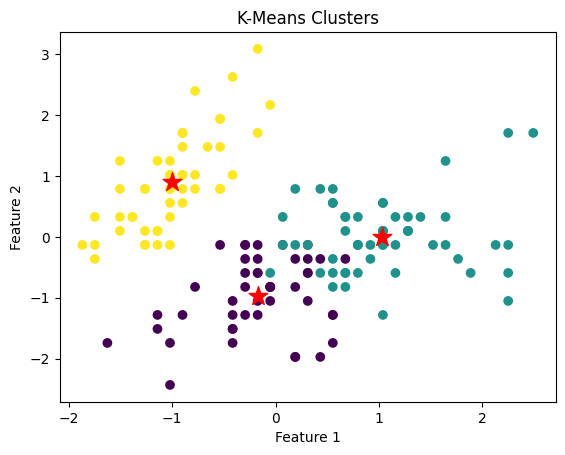

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# plt.figure(figsize=(4,3))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=labels)
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],marker='*', c='r',s=200)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clusters')
plt.show()

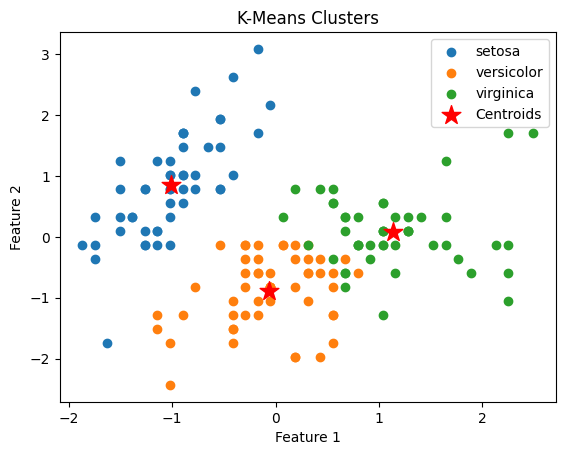

In [113]:
cluster_names = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

for i in range(3):
    plt.scatter(X_scaled[labels == i, 0],
                X_scaled[labels == i, 1],
                label=cluster_names[i])

# Plot centroids
plt.scatter(model.cluster_centers_[:, 0],
            model.cluster_centers_[:, 1],
            marker='*', c='red', s=200, label='Centroids')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clusters')

plt.legend()   # 🔥 THIS LINE ADDS LABELS
plt.show()

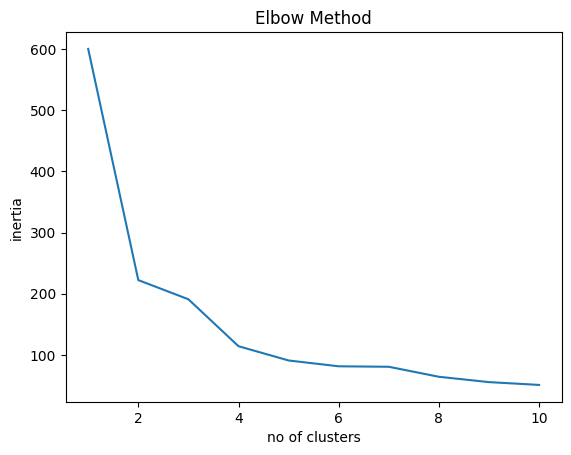

In [15]:
# to find no of clusters we use elbow method

inertia=[]
k_range=range(1,11)
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range,inertia)
plt.xlabel('no of clusters')
plt.ylabel('inertia')
plt.title('Elbow Method')
plt.show()
    